In [1]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import sem
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
import netCDF4
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot

## Call csv file
* save master sheet as the current date in 'mmddyyy.csv' format
* make a new column called 'date' and takes my'date of collection' column and makes it a datetime format

In [2]:
start_date = '2022-07-01T12:00:00'
end_date = '2023-04-06T12:00:00'

#data_path = r'../data/simplified_master_data.csv'
data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola/abiotic_data/simplified_master_data.csv'

a_sola_data = pd.read_csv(data_path)
a_sola_data['date_time'] = pd.to_datetime(a_sola_data['date_of_collection'])
a_sola_data = a_sola_data[(a_sola_data['date_time'] > start_date) & (a_sola_data['date_time'] <= end_date)]
a_sola_data['doy'] = a_sola_data['date_time'].dt.strftime('%j')
a_sola_data['doy'] = a_sola_data['doy'].astype(str).astype(int)

Alga Density

In [3]:
# Filter for non-null 'collection_group'
a_sola_algae_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on 'num_cells_per_ug_protein'
a_sola_algae_data = a_sola_algae_data[
    (~a_sola_algae_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_algae_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_algae_data['num_cells_per_ug_protein'] < 3000)
]
a_sola_algae_data = a_sola_algae_data.drop(columns='ng_chlorophyll_per_ug_protein')

# Extract 'doy' column and count the rows
algae_doy = a_sola_algae_data['doy']
num_rows = len(a_sola_algae_data)

print(num_rows)

380


Chlorophyll

In [4]:
# Filter for non-null 'collection_group'
a_sola_chlorophyll_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on required columns
a_sola_chlorophyll_data = a_sola_chlorophyll_data[
    (~a_sola_chlorophyll_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['ng_chlorophyll_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'] < 3000)
]

# Extract 'doy' column and count the rows
chl_doy = a_sola_chlorophyll_data['doy']
num_rows = len(a_sola_chlorophyll_data)

print(num_rows)


330


# Viewing each dependant variable's shape and testing for normalcy

[Text(0.5, 1.0, 'ng Chlorophyll per Animal Protein')]

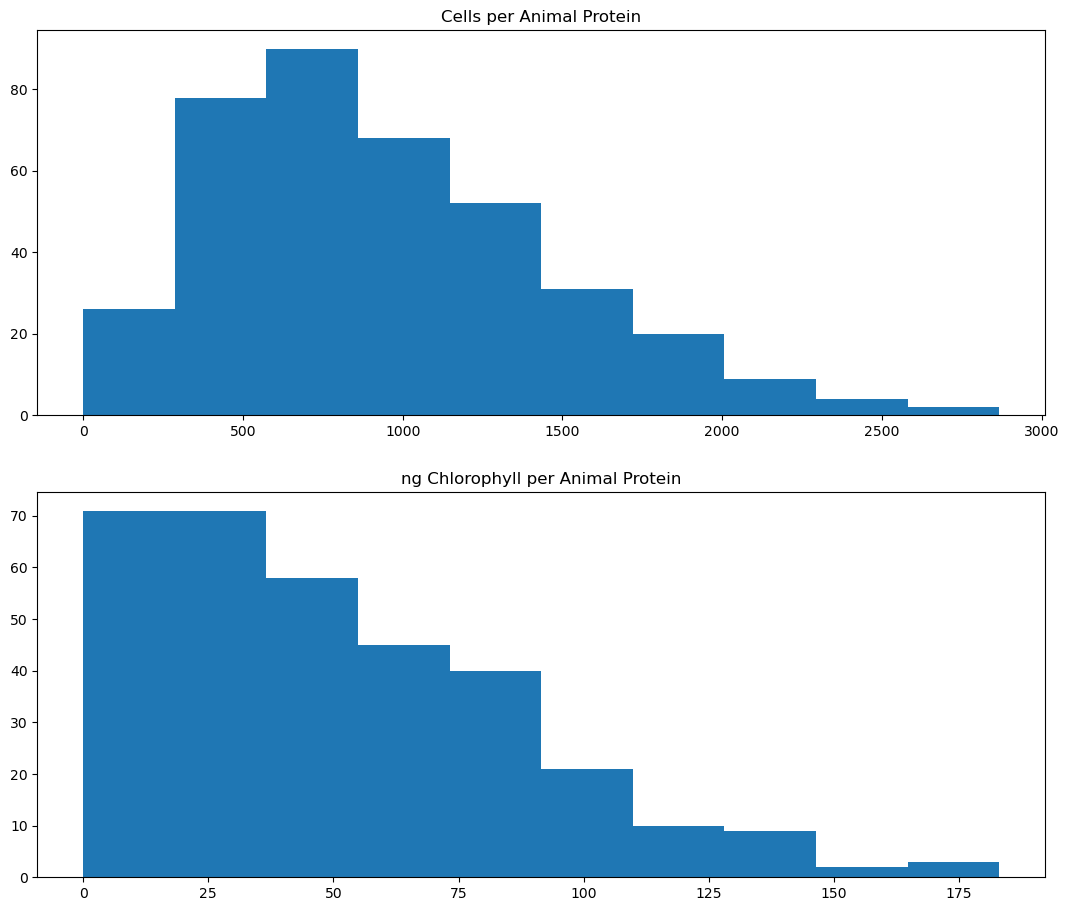

In [5]:
fig, (ax1, ax2)  = plt.subplots(2, 1, sharey=False, figsize=(13,11))

ax1.hist(a_sola_algae_data.num_cells_per_ug_protein)
ax1.set(title ='Cells per Animal Protein')

ax2.hist(a_sola_chlorophyll_data.ng_chlorophyll_per_ug_protein)
ax2.set(title ='ng Chlorophyll per Animal Protein')

In [6]:
print('Testing normalcy of algal density data:')
normalcy(a_sola_algae_data, 'num_cells_per_ug_protein')
print('')
print('Testing normalcy of chlorophyll concentration data:')
normalcy(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

Testing normalcy of algal density data:
ShapiroResult(statistic=0.9552969336509705, pvalue=2.4637145656924986e-09)

Testing normalcy of chlorophyll concentration data:
ShapiroResult(statistic=0.930269181728363, pvalue=2.6439853778592592e-11)


# Bar graphs

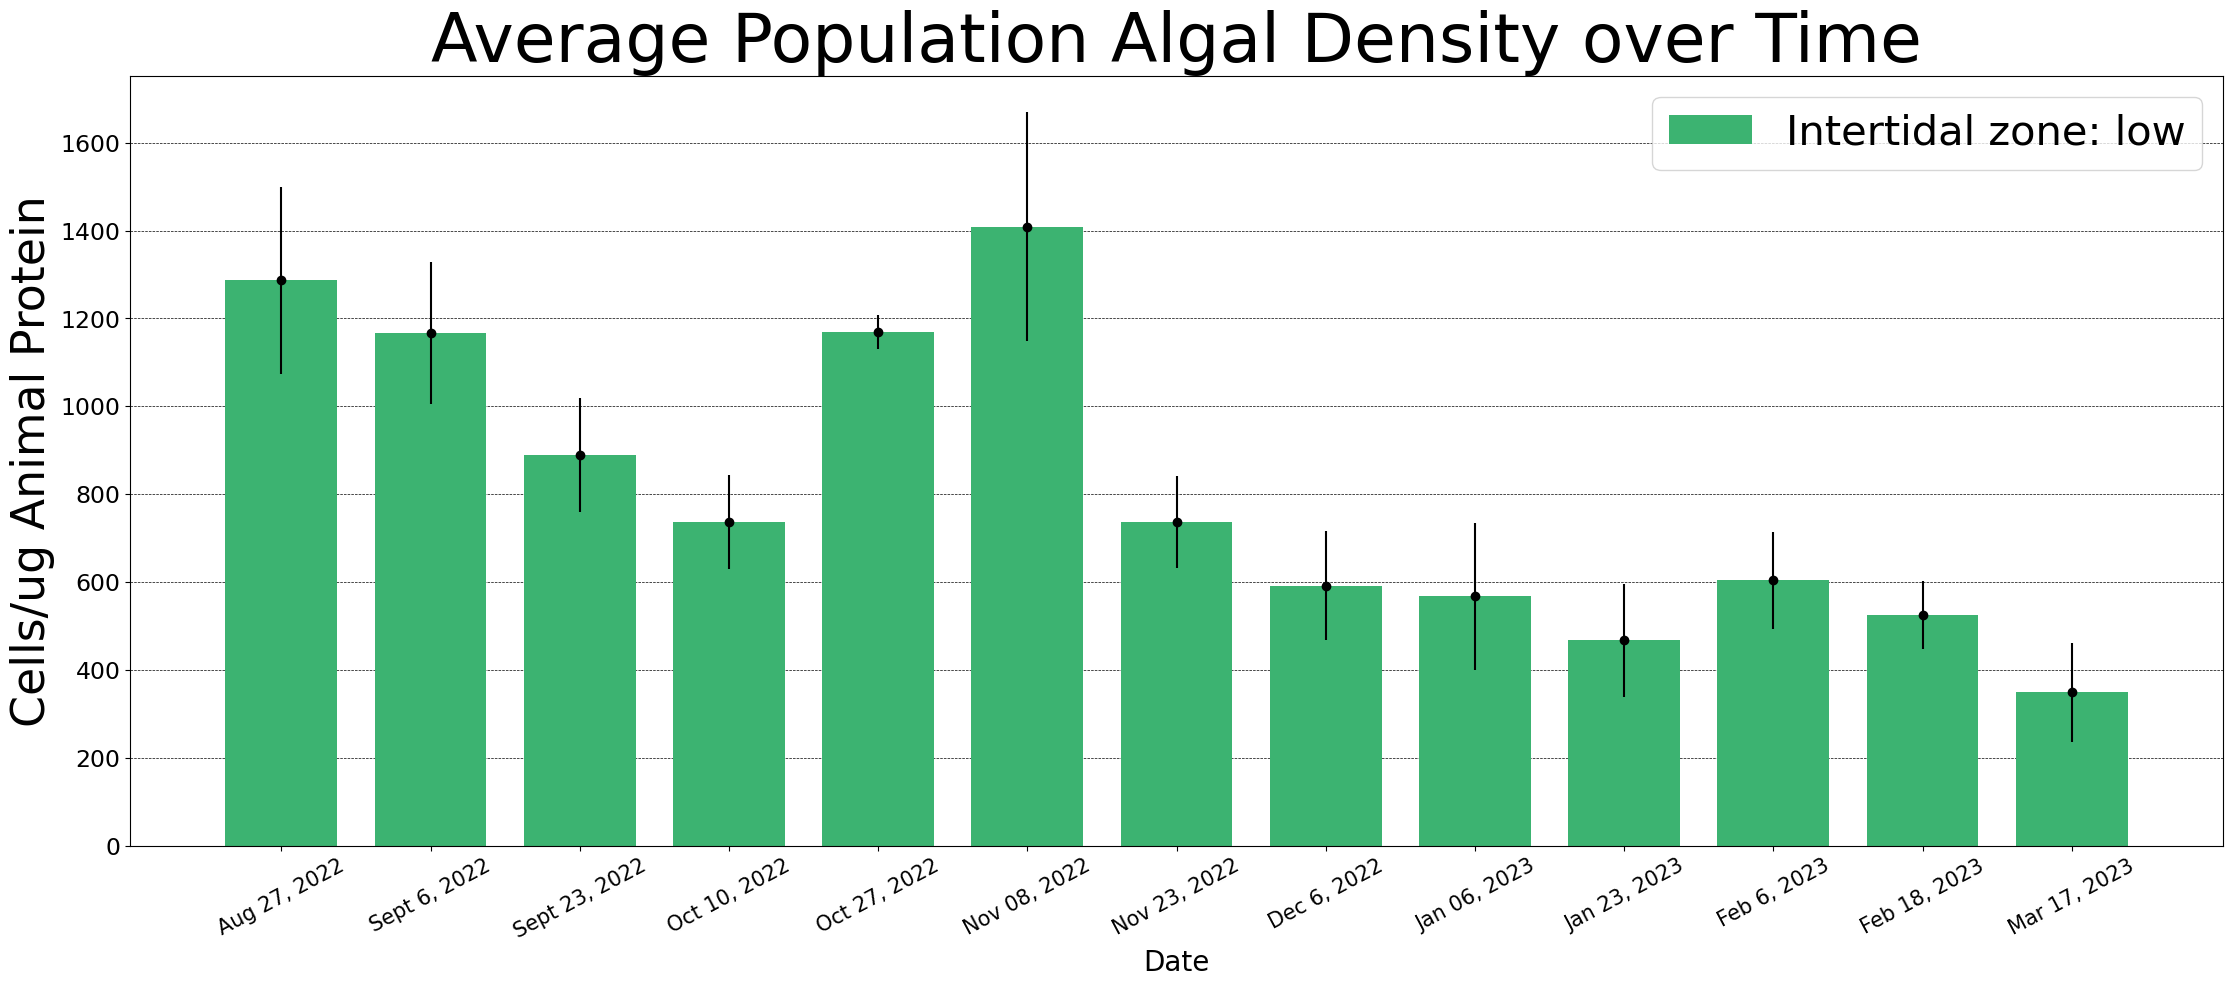

In [7]:
batch_bar(a_sola_algae_data, 'num_cells_per_ug_protein', 'low')

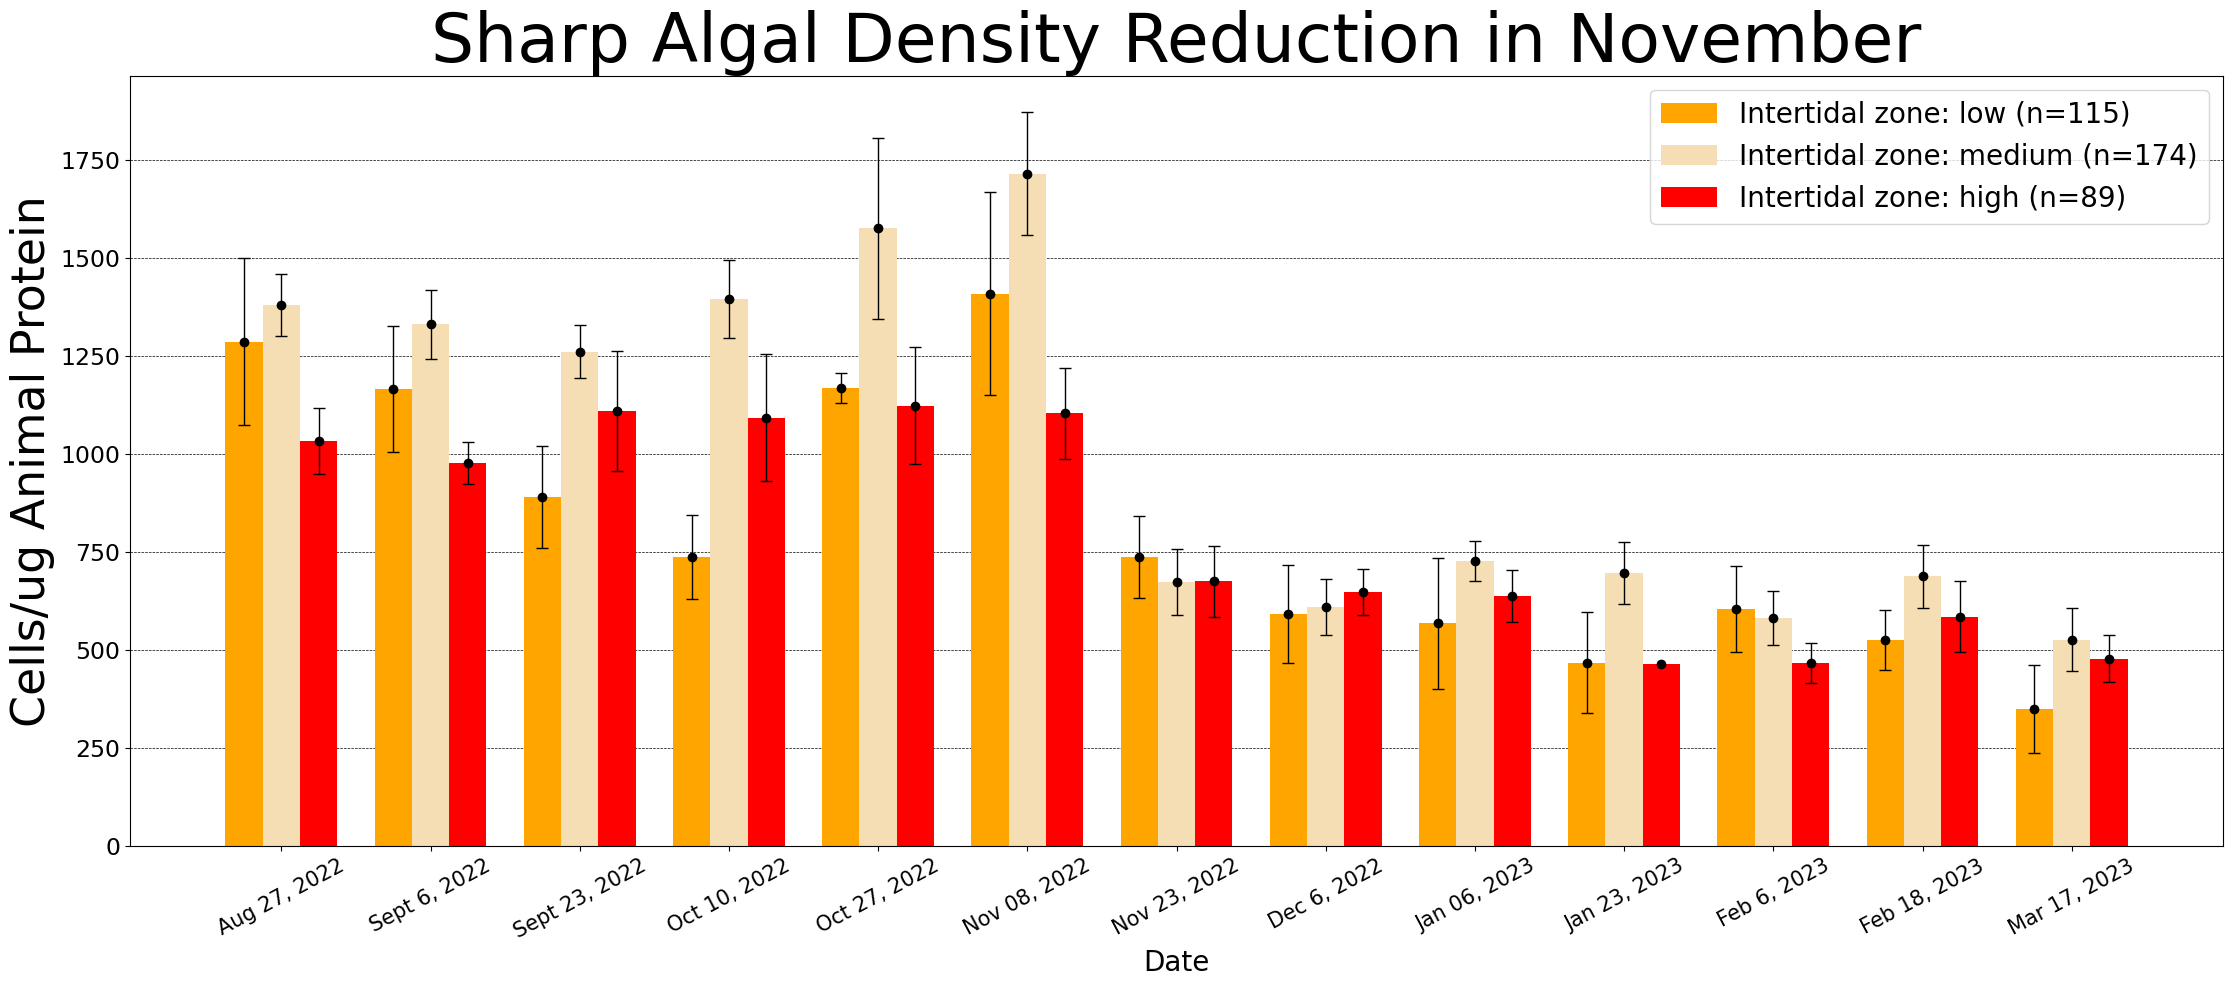

In [8]:
batch_bar_overlay(a_sola_algae_data, 'num_cells_per_ug_protein')

No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein


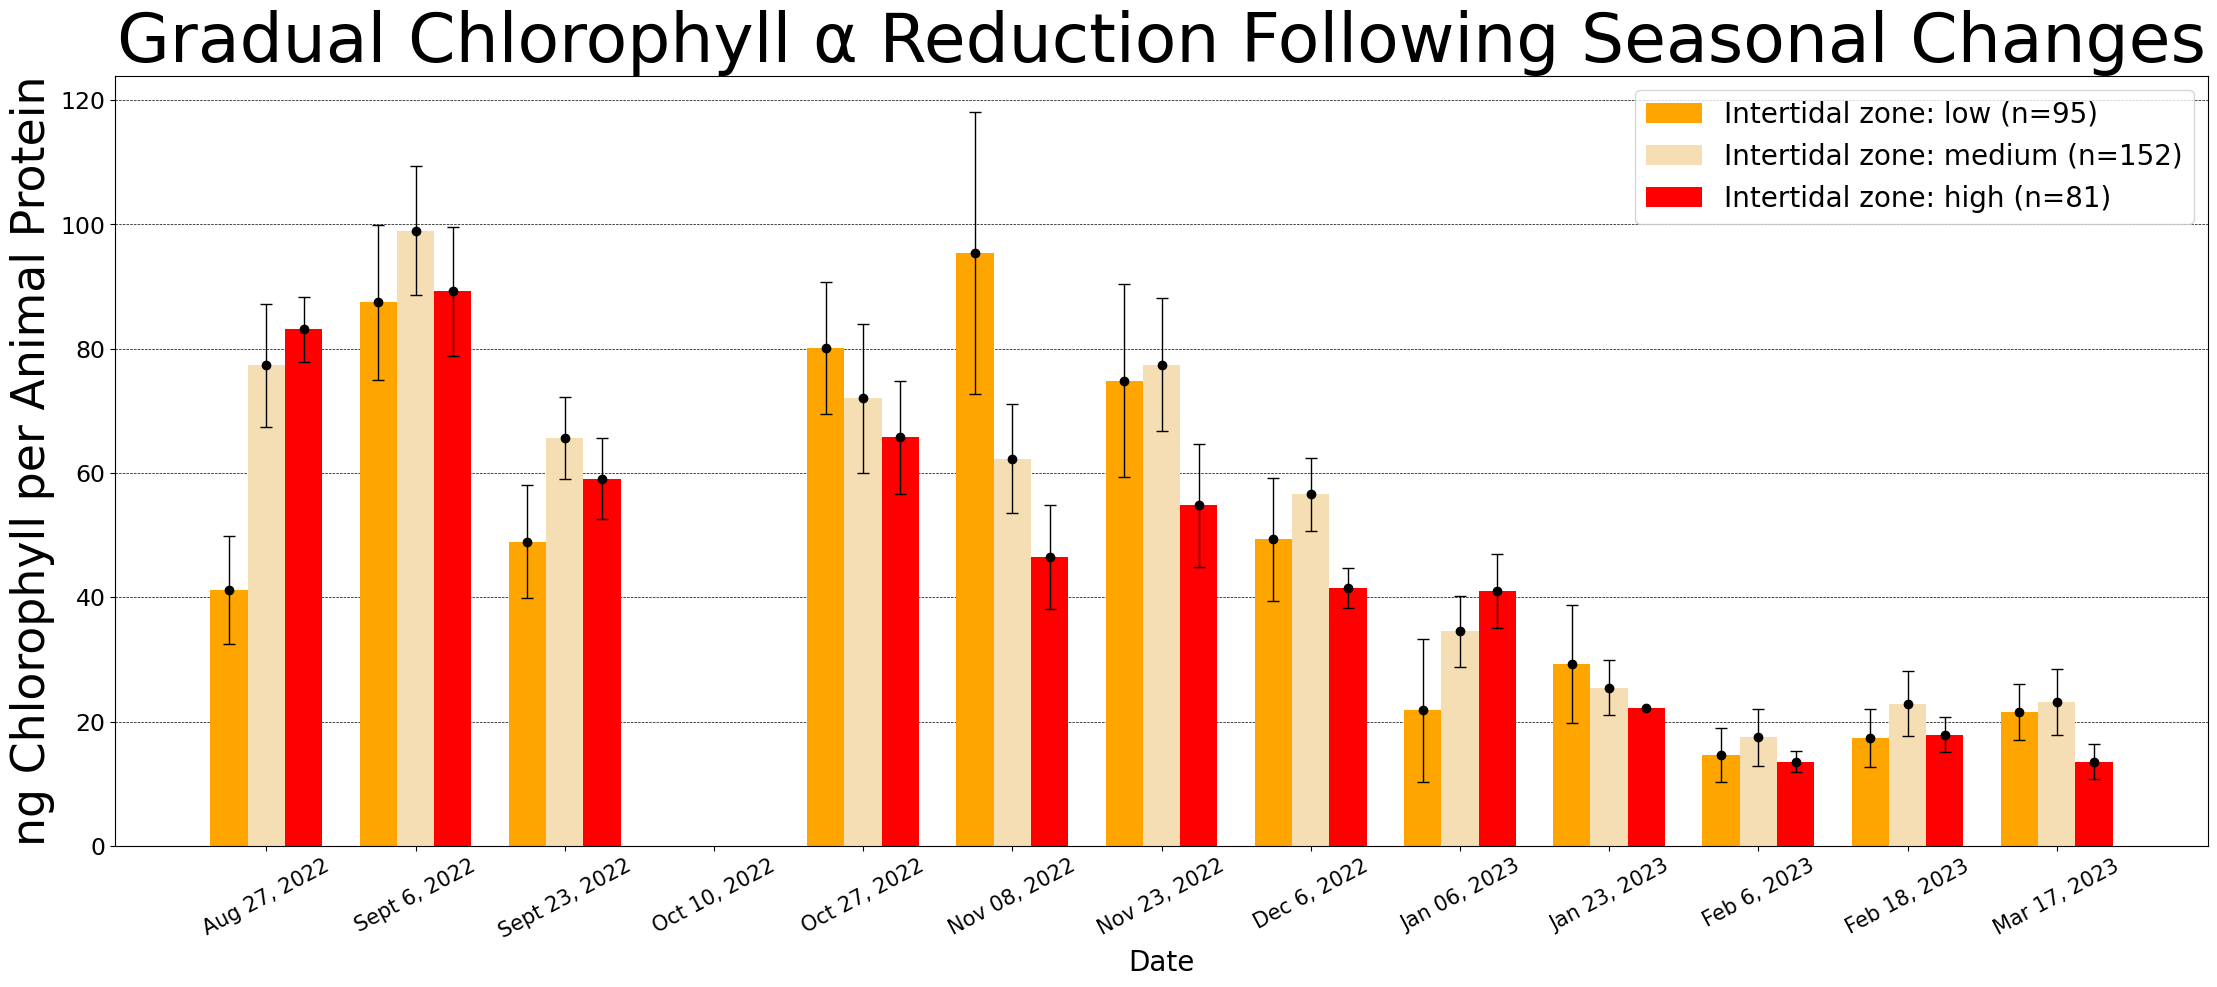

In [9]:
batch_bar_overlay(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

# Kruskal-Wallis test pre vs post drop observed in the bar graph
* can use individual tidal heights or all combines

In [10]:
kruskal_drops(a_sola_algae_data, 'num_cells_per_ug_protein', 'all')

Testing pre ShapiroResult(statistic=0.9885910749435425, pvalue=0.10484080761671066) vs post ShapiroResult(statistic=0.9921711087226868, pvalue=0.4551841616630554) drop normalcy
Testing all intertidal zones before vs after drop: KruskalResult(statistic=145.00073719598595, pvalue=2.1468405193222063e-33)


In [11]:
kruskal_drops(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', 'all')

Testing pre ShapiroResult(statistic=0.9643855094909668, pvalue=0.0005476570222526789) vs post ShapiroResult(statistic=0.8705012202262878, pvalue=3.324244005065147e-11) drop normalcy
Testing all intertidal zones before vs after drop: KruskalResult(statistic=86.93546383340731, pvalue=1.1212074601772981e-20)


# Testing statistical significance between intertidal zones

In [12]:
data = [a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="low"]['num_cells_per_ug_protein'],
        a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="medium"]['num_cells_per_ug_protein'],
        a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="high"]['num_cells_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

          1         2         3
1  1.000000  0.000025  0.409667
2  0.000025  1.000000  0.002603
3  0.409667  0.002603  1.000000


In [13]:
data = [a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="low"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="medium"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="high"]['ng_chlorophyll_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

          1         2         3
1  1.000000  0.119552  0.855470
2  0.119552  1.000000  0.158942
3  0.855470  0.158942  1.000000


# Intertidal zone box plot to visualize stats sfrom above

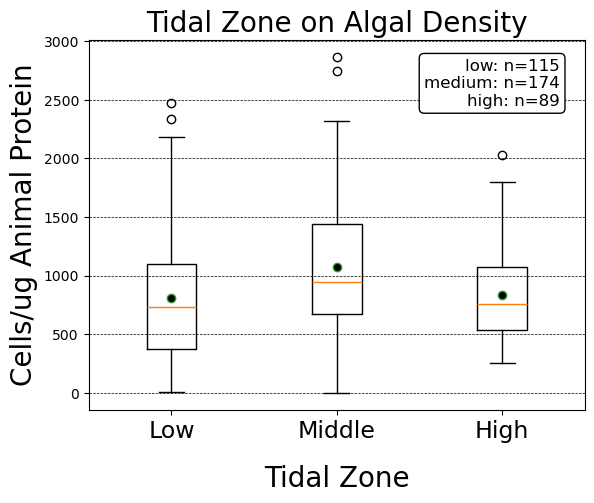

In [14]:
intertidal_box_plot(a_sola_algae_data, 'num_cells_per_ug_protein')

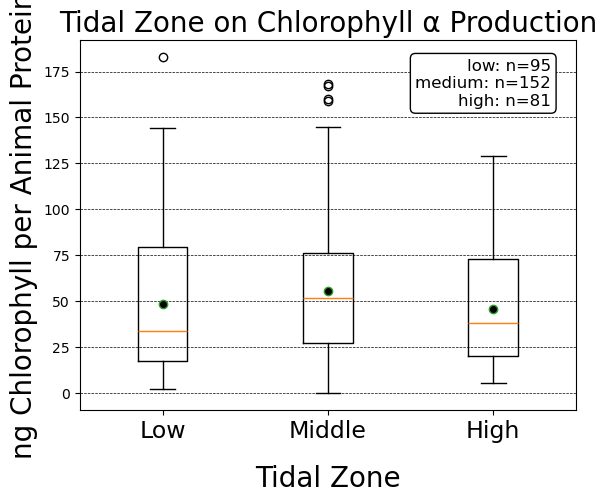

In [15]:
intertidal_box_plot(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

# Logger Data

# Running some regression models

In [ ]:
# Adapted from https://www.statsmodels.org/stable/examples/notebooks/generated/mixed_lm_example.html

import statsmodels.api as sm
import statsmodels.formula.api as smf


# Run LMER
md = smf.mixedlm('num_cells_per_ug_protein ~ collection_group', final_algae_data, groups=final_algae_data["nickname"], re_formula="~collection_group")
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

                     Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    num_cells_per_ug_protein
No. Observations:     380        Method:                REML                    
No. Groups:           62         Scale:                 127036.2567             
Min. group size:      1          Log-Likelihood:        -2796.5035              
Max. group size:      18         Converged:             No                      
Mean group size:      6.1                                                       
--------------------------------------------------------------------------------
                               Coef.    Std.Err.    z    P>|z|  [0.025   0.975] 
--------------------------------------------------------------------------------
Intercept                      1637.967   85.262  19.211 0.000 1470.856 1805.078
collection_group                -74.326    6.230 -11.931 0.000  -86.536  -62.116
Group Var                    154354.830  102.105  

In [ ]:
par3_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdMH1par08day_R2022NRT'

start_time = '2022-08-10T00:00:00'
end_time = '2023-04-22T00:00:00'

par_day = xr.open_dataset(par3_url)

# Find the nearest latitude value to 37.59
latitude_value = 37.59
latitudes = par_day['latitude'].values
nearest_latitude = latitudes[np.argmin(np.abs(latitudes - latitude_value))]

#print(f"Nearest Latitude: {nearest_latitude}")

longitude_value = -122.5
longitude = par_day['longitude'].values
nearest_longitude = longitude[np.argmin(np.abs(longitude - longitude_value))]



# Use the nearest latitude value to select the data
our_par = par_day['par'].sel(
    latitude=nearest_latitude,
    longitude=nearest_longitude,
    time=slice(start_time, end_time)
)

In [ ]:
par = pd.DataFrame(our_par)

# Convert both date columns to datetime
final_chl_data['compatible_date'] = pd.to_datetime(final_chl_data['date_of_collection'])
par['compatible_date'] = pd.to_datetime(our_par['time'])

# Sort both dataframes by the date column
final_chl_data.sort_values('compatible_date', inplace=True)
par.sort_values('compatible_date', inplace=True)

# Perform an asof merge
par_chl = pd.merge_asof(final_chl_data, par, on='compatible_date', direction='nearest')

In [ ]:
par_chl

,specimen_number,specimen_id,nickname,processing_group_flow,collection_group,date_of_collection,location,pair_group,intertidal_zone,vertical_tidal_height,...,chlorophyll_per_ug_protein,ng_chlorophyll_per_ug_protein,ng_chlorophyll_per_hundred_cells,batch_notes,notes,date_time,doy,within_range_column,compatible_date,0
0,197.0,1.0,Ava,4.0,4.0,2022-08-27,Rockaway,1.0,low,1.749425,...,0.012439,12.439312,4.19,NaN,NaN,2022-08-27,239,within_range,2022-08-27,42.478001
1,220.0,25.0,Tyler,4.0,4.0,2022-08-27,Rockaway,12.0,high,1.196975,...,0.069636,69.635607,8.77,NaN,NaN,2022-08-27,239,within_range,2022-08-27,42.478001
2,219.0,24.0,Jerett,4.0,4.0,2022-08-27,Rockaway,12.0,high,1.196975,...,0.078920,78.920094,6.59,NaN,NaN,2022-08-27,239,within_range,2022-08-27,42.478001
3,218.0,30.0,Julian,4.0,4.0,2022-08-27,Rockaway,NaN,high,1.301750,...,0.099493,99.493416,7.46,NaN,NaN,2022-08-27,239,within_range,2022-08-27,42.478001
4,217.0,29.0,James,4.0,4.0,2022-08-27,Rockaway,NaN,high,1.362075,...,0.090270,90.270237,10.37,NaN,NaN,2022-08-27,239,within_range,2022-08-27,42.478001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,569.0,NaN,uppertidenine,14.0,16.0,2023-03-17,Rockaway,NaN,high,NaN,...,0.029878,29.877697,3.97,NaN,NaN,2023-03-17,76,outside_range,2023-03-17,29.336000
325,568.0,25.0,Tyler,14.0,16.0,2023-03-17,Rockaway,12.0,high,1.196975,...,0.005394,5.393961,1.83,NaN,NaN,2023-03-17,76,outside_range,2023-03-17,29.336000
326,567.0,34.0,Ray,14.0,16.0,2023-03-17,Rockaway,13.0,high,1.101725,...,0.009823,9.823447,2.40,NaN,NaN,2023-03-17,76,outside_range,2023-03-17,29.336000
327,578.0,32.0,Upper,14.0,16.0,2023-03-17,Rockaway,NaN,medium,1.063625,...,0.031335,31.335338,3.97,NaN,NaN,2023-03-17,76,outside_range,2023-03-17,29.336000


In [ ]:
# Group the merged DataFrame 'par_chl' by 'compatible_date' and calculate the mean of 'chlor' for each group
grouped_par_chl = par_chl.groupby('compatible_date')['ng_chlorophyll_per_ug_protein'].mean().reset_index()

# Rename the 'chlor' column to 'average_chlor'
grouped_par_chl.rename(columns={'ng_chlorophyll_per_ug_protein': 'average_chlor'}, inplace=True)

# Merge the '0' column from 'par_chl' to 'grouped_par_chl' based on 'compatible_date'
grouped_par_chl = grouped_par_chl.merge(par_chl[['compatible_date', 0]], on='compatible_date')
grouped_par_chl.rename(columns={0: 'par'}, inplace=True)

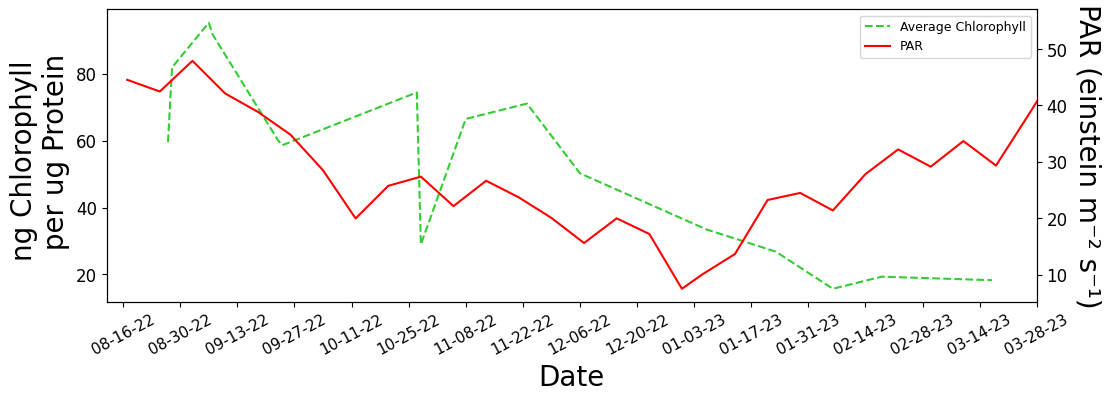

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'

ax.plot(grouped_par_chl['compatible_date'], grouped_par_chl['average_chlor'], color = 'limegreen', label = 'Average Chlorophyll', linestyle = 'dashed')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(our_par.time, our_par, color = 'red', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)


#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

In [ ]:
# Group the 'par_chl' DataFrame by 'compatible_date' and 'intertidal_zone', and calculate the mean of 'ng_chlorophyll_per_ug_protein' for each group
grouped_par_chl = par_chl.groupby(['compatible_date', 'intertidal_zone'])['ng_chlorophyll_per_ug_protein'].mean().reset_index()

# Rename the 'ng_chlorophyll_per_ug_protein' column to 'average_chlor'
grouped_par_chl.rename(columns={'ng_chlorophyll_per_ug_protein': 'average_chlor'}, inplace=True)

# Create separate DataFrames for each intertidal zone
low_intertidal_zone_df = grouped_par_chl[grouped_par_chl['intertidal_zone'] == 'low'].copy()
medium_intertidal_zone_df = grouped_par_chl[grouped_par_chl['intertidal_zone'] == 'medium'].copy()
high_intertidal_zone_df = grouped_par_chl[grouped_par_chl['intertidal_zone'] == 'high'].copy()

# Drop the 'intertidal_zone' column from each DataFrame as it's no longer needed
low_intertidal_zone_df.drop(columns='intertidal_zone', inplace=True)
medium_intertidal_zone_df.drop(columns='intertidal_zone', inplace=True)
high_intertidal_zone_df.drop(columns='intertidal_zone', inplace=True)


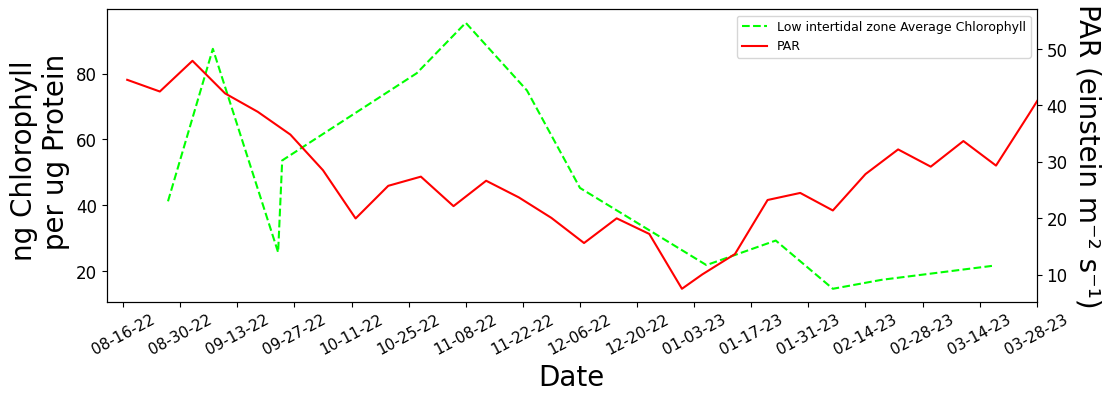

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'

ax.plot(low_intertidal_zone_df['compatible_date'], low_intertidal_zone_df['average_chlor'], color = 'lime', label = 'Low intertidal zone Average Chlorophyll', linestyle = 'dashed')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(our_par.time, our_par, color = 'red', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)


#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'

ax.plot(medium_intertidal_zone_df['compatible_date'], medium_intertidal_zone_df['average_chlor'], color = 'darkseagreen', label = 'Middle intertidal zone Average Chlorophyll', linestyle = 'dashed')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(our_par.time, our_par, color = 'red', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)


#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'

ax.plot(high_intertidal_zone_df['compatible_date'], high_intertidal_zone_df['average_chlor'], color = 'forestgreen', label = 'High intertidal zone Average Chlorophyll', linestyle = 'dashed')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(our_par.time, our_par, color = 'red', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)


#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

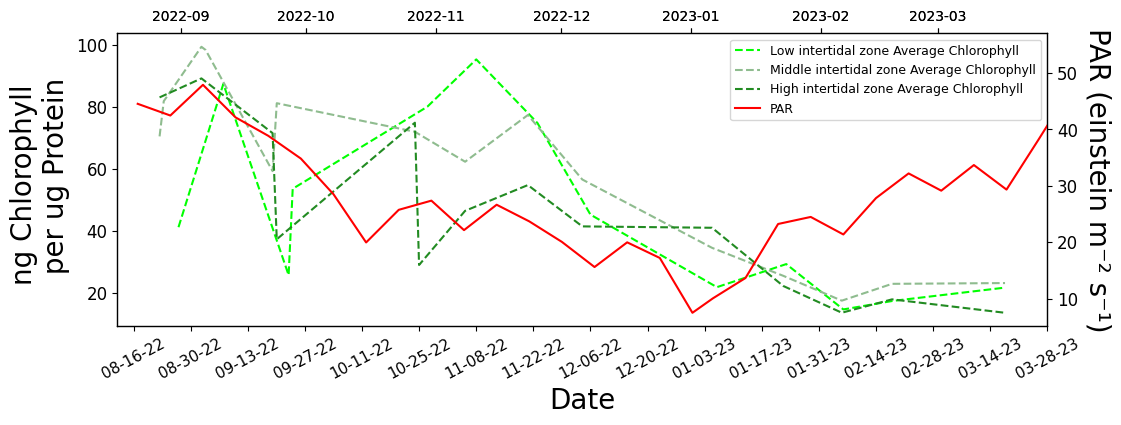

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'


ax.plot(low_intertidal_zone_df['compatible_date'], low_intertidal_zone_df['average_chlor'], color = 'lime', label = 'Low intertidal zone Average Chlorophyll', linestyle = 'dashed')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twiny()
ax2.plot(medium_intertidal_zone_df['compatible_date'], medium_intertidal_zone_df['average_chlor'], color = 'darkseagreen', label = 'Middle intertidal zone Average Chlorophyll', linestyle = 'dashed')


ax3 = ax.twiny()
ax3.plot(high_intertidal_zone_df['compatible_date'], high_intertidal_zone_df['average_chlor'], color = 'forestgreen', label = 'High intertidal zone Average Chlorophyll', linestyle = 'dashed')

ax4 = ax.twinx() #to plot a second y axis
ax4.plot(our_par.time, our_par, color = 'red', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")

ax4.tick_params(axis='y', labelsize=12)
ax4.yaxis.label.set_size(20)

#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax4.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 +labels4, loc='upper right', fontsize = 9)

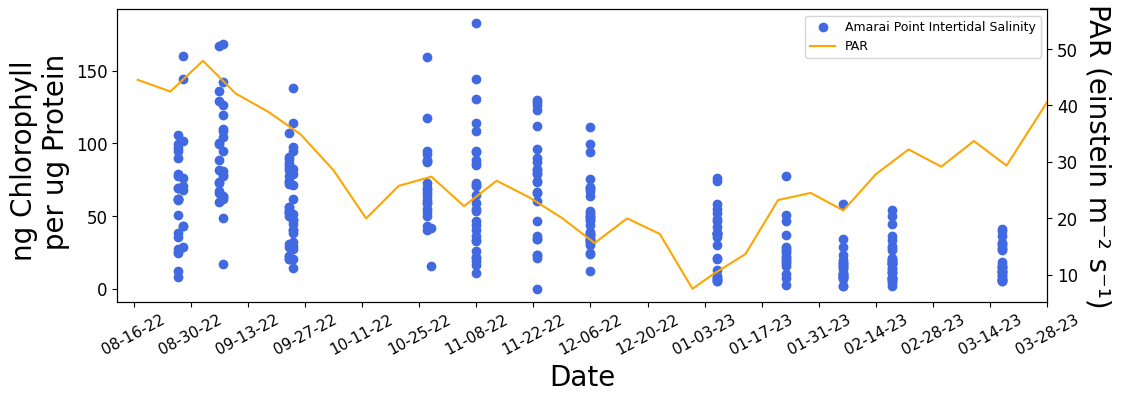

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))

start_date = '2022-08-12T00:00:00'
end_date = '2023-03-28T00:00:00'

ax.scatter(final_chl_data['date_time'], final_chl_data['ng_chlorophyll_per_ug_protein'], color = 'royalblue', label = 'Amarai Point Intertidal Salinity')
ax.set(xlabel = "Date", ylabel='ng Chlorophyll \n per ug Protein')
#ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(our_par.time, our_par, color = 'orange', label = 'PAR')
plt.ylabel('PAR (einstein m⁻² s⁻¹)', fontsize=10, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)


#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

In [ ]:
upwelling_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo_LonPM180'

start_time = '2022-08-10T00:00:00'
end_time = '2023-04-22T00:00:00'

upwelling_month = xr.open_dataset(upwelling_url)
'''
# Find the nearest latitude value to 37.59
latitude_value = 37.59
latitudes = par_day['latitude'].values
nearest_latitude = latitudes[np.argmin(np.abs(latitudes - latitude_value))]

#print(f"Nearest Latitude: {nearest_latitude}")

longitude_value = -122.5
longitude = par_day['longitude'].values
nearest_longitude = longitude[np.argmin(np.abs(longitude - longitude_value))]



# Use the nearest latitude value to select the data
our_par = par_day['par'].sel(
    latitude=nearest_latitude,
    longitude=nearest_longitude,
    time=slice(start_time, end_time)
)
'''

RuntimeError: ignored

In [ ]:
upwelling_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo.csv?upwelling_index%5B(2022-01-15):1:(2023-09-15T00:00:00Z)%5D%5B(36.0):1:(36.0)%5D%5B(238.0):1:(238)%5D,upwelling_index_anomaly%5B(2022-01-15):1:(2023-09-15T00:00:00Z)%5D%5B(36.0):1:(36.0)%5D%5B(238.0):1:(238)%5D'
pd.read_csv(upwelling_url)

HTTPError: ignored

In [ ]:
merged_plot(final_chl_data, 'date_time', 'ng_chlorophyll_per_ug_protein', our_par, 'salinity(ppt)')

In [ ]:
#display(hobo_data)

In [ ]:
#display(algae_hobo_seven)

In [ ]:
display(algae_star_fourteen)

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.plot(star_average['date_time'], star_average['temp(c)'], color = 'royalblue', zorder = 3)
ax.plot(hobo_average['date_time'], hobo_average['temp(c)'], color = 'orange', zorder = 2)
ax.plot(ap_beach.time, ap_beach.mean(axis=(1,2)), label = 'Amarai Point', zorder = 1, color = 'indigo')

ax.set_title('Sea Surface Temperature among Three Sources', fontsize =30)
ax.set(ylabel='Temp (c)')
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
'''
ax.tick_params(axis='x', labelsize=12, rotation = 28, labelbottom=True)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)
ax.set_ylim(10, 20)
'''
lgnd = ax.legend([('Star Oddi Temperature Logger'),('HOBO Temperature Logger'),('Satellite')], loc = 'best', fontsize = 15)
#lgnd = ax.legend(loc="lower left", scatterpoints=1, fontsize=10)
lgnd.legendHandles[0]._sizes = [30]
lgnd.legendHandles[1]._sizes = [30]
#ax.grid(False)

In [ ]:
#merged_plot(algae_star_min, 'date_time', 'num_cells_per_ug_protein', algae_star_min, 'salinity(ppt)')
#merged_plot(algae_star_average, 'date_time', 'num_cells_per_ug_protein', algae_star_average, 'salinity(ppt)')
#merged_plot(algae_star_seven, 'date_time', 'num_cells_per_ug_protein', algae_star_seven, 'seven_day_salinity')

In [ ]:
display(algae_fp_seven_hr)

In [ ]:
regression(algae_fp_seven_hr, 'seven_day_salinity', 'num_cells_per_ug_protein', 'Average salinity one week \n prior to collection FORT POINT')

In [ ]:
regression(algae_star_average, 'salinity(ppt)', 'Salinity', 'num_cells_per_ug_protein', 'Average salinity \n on collection day')

In [ ]:
low_algae_star_seven = algae_star_seven[(algae_star_seven['intertidal_zone'] == 'low')]
med_algae_star_seven = algae_star_seven[(algae_star_seven['intertidal_zone'] == 'medium')]
high_algae_star_seven = algae_star_seven[(algae_star_seven['intertidal_zone'] == 'high')]

In [ ]:
regression(low_algae_star_seven, 'seven_day_salinity', 'num_cells_per_ug_protein', 'Average salinity 1 week \n prior to collection (low!)')

In [ ]:
regression(algae_star_three, 'three_day_salinity', 'num_cells_per_ug_protein', 'Average salinity 3 days \n prior to collection')

In [ ]:
regression(algae_star_three, 'three_day_temp', 'num_cells_per_ug_protein', 'Average temp 3 days \n prior to collection')

In [ ]:
regression(med_algae_star_seven, 'seven_day_salinity', 'num_cells_per_ug_protein', 'Average salinity 1 week \n prior to collection (middle!)')

In [ ]:
regression(high_algae_star_seven, 'seven_day_salinity', 'num_cells_per_ug_protein', 'Average salinity 1 week \n prior to collection (high!)')

In [ ]:
regression(chlor_star_seven, 'seven_day_salinity', 'ng_chlorophyll_per_ug_protein', 'Average salinity 1 week \n prior to collection')

In [ ]:
regression(chlor_star_fourteen, 'fourteen_day_salinity', 'ng_chlorophyll_per_ug_protein', 'Average salinity 2 weeks \n prior to collection')

In [ ]:
regression(chlor_star_average, 'salinity(ppt)', 'Salinity(ppt)', 'ng_chlorophyll_per_ug_protein', 'Average salinity \n on collection day')

In [ ]:
regression(chlor_star_average, 'temp(c)', 'Temp(c)', 'ng_chlorophyll_per_ug_protein', 'Average temperature \n on collection day')

In [ ]:
regression(chlor_star_seven, 'seven_day_temp', 'Temp(c)', 'ng_chlorophyll_per_ug_protein', 'Average temperature 1 week \n prior to collection')

In [ ]:
regression(chlor_star_fourteen, 'fourteen_day_temp', 'Temp(c)', 'ng_chlorophyll_per_ug_protein', 'Average temperature 2 weeks \n prior to collection')

In [ ]:
rockaway_daylength_algae = []
for i in algae_doy:
  P = math.asin(0.39795 * math.cos(0.2163108 + 2 * math.atan(0.9671396 * math.tan(.00860 * (i - 186)))))
  pi = math.pi
  day_light_hours = 24 - (24 / pi) * math.acos((math.sin(0.8333 * pi / 180) + math.sin(37.607 * pi / 180) * math.sin(P)) / (math.cos(37.607 * pi / 180) * math.cos(P)))
  rockaway_daylength_algae.append(day_light_hours)

rockaway_daylength_algae = np.array(rockaway_daylength_algae)
rockaway_daylength_algae =rockaway_daylength_algae.reshape(-1,1)
rockaway_daylength_algae = np.squeeze(rockaway_daylength_algae)

rockaway_daylength_chl = []
for i in chl_doy:
  P = math.asin(0.39795 * math.cos(0.2163108 + 2 * math.atan(0.9671396 * math.tan(.00860 * (i - 186)))))
  pi = math.pi
  day_light_hours = 24 - (24 / pi) * math.acos((math.sin(0.8333 * pi / 180) + math.sin(37.607 * pi / 180) * math.sin(P)) / (math.cos(37.607 * pi / 180) * math.cos(P)))
  rockaway_daylength_chl.append(day_light_hours)

rockaway_daylength_chl = np.array(rockaway_daylength_chl)
rockaway_daylength_chl =rockaway_daylength_chl.reshape(-1,1)
rockaway_daylength_chl = np.squeeze(rockaway_daylength_chl)

In [ ]:
sns.regplot(x=rockaway_daylength_algae, y= final_algae_data['num_cells_per_ug_protein'])
plt.ylabel('Cells/ug Animal Protein', fontsize=15, color='black')
plt.xlabel('Daylight (hrs)', fontsize=15, color='black')
plt.title("Daylight hours on Algae Density", fontsize=20, color='black')


slope, intercept, r_value, p_value, std_err = linregress(x=rockaway_daylength_algae, y=final_algae_data['num_cells_per_ug_protein'])

regression_stats = {
'slope': slope,
'intercept': intercept,
'r_value': r_value,
'p_value': p_value,
'std_err': std_err
    }

print(regression_stats)

In [ ]:
sns.regplot(x=rockaway_daylength_chl, y= final_chl_data['ng_chlorophyll_per_ug_protein'])
plt.ylabel('Cells/ug Animal Protein', fontsize=15, color='black')
plt.xlabel('Daylight (hrs)', fontsize=15, color='black')
plt.title("Daylight hours on Chlorophyll Concentration", fontsize=20, color='black')


slope, intercept, r_value, p_value, std_err = linregress(x=rockaway_daylength_chl, y=final_chl_data['ng_chlorophyll_per_ug_protein'])

regression_stats = {
'slope': slope,
'intercept': intercept,
'r_value': r_value,
'p_value': p_value,
'std_err': std_err
    }

print(regression_stats)

In [ ]:
your_data1 = algae_hobo_seven  # Replace with your actual dataset 1
your_data2 = algae_star_seven # Replace with your actual dataset 2


data_list = [your_data1, your_data2]

xvar = 'temp(c)'  # Replace with the desired x-variable name
yvar = 'num_cells_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'Seven Day Average Hobo', 1: 'Seven Day Average Star'}  # Assign custom labels based on dataset positions
colors = ['red', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
your_data1 = algae_star_average  # Replace with your actual dataset 1
your_data2 = algae_star_min  # Replace with your actual dataset 2
your_data3 = algae_star_seven  # Replace with your actual dataset 3

data_list = [your_data1, your_data2, your_data3]

xvar = 'salinity(ppt)'  # Replace with the desired x-variable name
yvar = 'num_cells_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'Day of Collection Average', 1: 'Day of Collection Minimum', 2: 'Week Long Average Prior'}  # Assign custom labels based on dataset positions
colors = ['red', 'green', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
your_data1 = chlor_star_average  # Replace with your actual dataset 1
your_data2 = chlor_star_min  # Replace with your actual dataset 2
your_data3 = chlor_star_seven  # Replace with your actual dataset 3

data_list = [your_data1, your_data2, your_data3]

xvar = 'salinity(ppt)'  # Replace with the desired x-variable name
yvar = 'ng_chlorophyll_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'Day of Collection Average', 1: 'Day of Collection Minimum', 2: 'Week Long Average Prior'}  # Assign custom labels based on dataset positions
colors = ['red', 'green', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
your_data1 = algae_star_seven  # Replace with your actual dataset 1
your_data2 = algae_fp_seven_hr # Replace with your actual dataset 2

data_list = [your_data1, your_data2]

xvar = 'salinity(ppt)'  # Replace with the desired x-variable name
yvar = 'num_cells_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'Seven Day Avg Star Oddi Logger (20 min interval)', 1: 'Seven Day Avg Fort Point Data (Hourly Interval)'}  # Assign custom labels based on dataset positions
colors = ['red', 'green', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
your_data1 = algae_star_average  # Replace with your actual dataset 1
your_data2 = algae_star_min  # Replace with your actual dataset 2
your_data3 = algae_star_seven  # Replace with your actual dataset 3

data_list = [your_data1, your_data2, your_data3]

xvar = 'temp(c)'  # Replace with the desired x-variable name
yvar = 'num_cells_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'algae hobo average', 1: 'algae hobo minimum', 2: 'algae hobo seven'}  # Assign custom labels based on dataset positions
colors = ['red', 'green', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
your_data1 = algae_hobo_average  # Replace with your actual dataset 1
your_data2 = algae_hobo_min  # Replace with your actual dataset 2
your_data3 = algae_hobo_seven  # Replace with your actual dataset 3

data_list = [your_data1, your_data2, your_data3]

xvar = 'temp(c)'  # Replace with the desired x-variable name
yvar = 'num_cells_per_ug_protein'  # Replace with the desired y-variable name

label_keywords = {0: 'algae hobo average', 1: 'algae hobo minimum', 2: 'algae hobo seven'}  # Assign custom labels based on dataset positions
colors = ['red', 'green', 'blue']

multi_regression(data_list, xvar, yvar, label_keywords)

In [ ]:
final_algae_data['three_day_avg_algae'] = None

for index, row in final_algae_data.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=2)
    end_date = collection_date + timedelta(days=2)
    #print('start date:', start_date)
    #print('end date:', end_date)

    # Filter temp data within the date range
    algae_three_day_subset = final_algae_data[(final_algae_data['date_time'] >= start_date) & (final_algae_data['date_time'] <= end_date)]


    # Calculate the average algae
    algae_three_day_avg = algae_three_day_subset['num_cells_per_ug_protein'].mean()

    final_algae_data.at[index, 'three_day_avg_algae'] = algae_three_day_avg


In [ ]:
final_chl_data['three_day_avg_chl'] = None

for index, row in final_chl_data.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=2)
    end_date = collection_date + timedelta(days=2)
    #print('start date:', start_date)
    #print('end date:', end_date)

    # Filter temp data within the date range
    chl_three_day_subset = final_chl_data[(final_chl_data['date_time'] >= start_date) & (final_chl_data['date_time'] <= end_date)]


    chl_three_day_avg = chl_three_day_subset['ng_chlorophyll_per_ug_protein'].mean()

    final_chl_data.at[index, 'three_day_avg_chl'] = chl_three_day_avg

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.plot(final_algae_data['date_time'], final_algae_data['three_day_avg_algae'], color = 'orange', label = 'Average Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precip_date, precip_rain, width = 1.3, color = 'dodgerblue', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)
#ax.set_title('Average Collection Values and Rainfall', fontsize =25)

n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Average Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)


plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.plot(final_chl_data['date_time'], final_chl_data['three_day_avg_chl'], color = 'green', label = 'Average Chlorophyll a Concentration')
plt.ylabel('ng Chlorophyll \n per Animal Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precip_date, precip_rain, width = 1.3, color = 'dodgerblue', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)
#ax.set_title('Average Collection Values and Rainfall', fontsize =25)

n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Average Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)


plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.plot(final_chl_data['date_time'], final_chl_data['three_day_avg_chl'], color = 'green', label = 'Average Chlorophyll a Concentration')
plt.ylabel('ng Chlorophyll \n per Animal Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(star_average['date_time'], star_average['temp(c)'],  color = 'red', label = 'Temperature(c)')
plt.ylabel('Temperature (c)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)
#ax.set_title('Average Collection Values and Rainfall', fontsize =25)

n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Average Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)


plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.plot(final_algae_data['date_time'], final_algae_data['three_day_avg_algae'], color = 'orange', label = 'Average Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(star_average['date_time'], star_average['temp(c)'],  color = 'red', label = 'Temperature(c)')
plt.ylabel('Temperature (c)', fontsize=15, rotation= 270, va="bottom")
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)
#ax.set_title('Average Collection Values and Rainfall', fontsize =25)

n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Average Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)


plt.show()

In [ ]:
average_salinity = algae_star_seven['seven_day_salinity'].mean()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(final_algae_data['date_time'], final_algae_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Algal Density')
ax.plot(algae_star_three['date_time'], algae_star_three['three_day_salinity'], color = 'royalblue', label = 'Average Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precip_date, precip_rain, width = 1.3, color = 'orange', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

#ax.set_title('All Algal Collection Values and Rainfall', fontsize =25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
#ax.scatter(final_chl_data['date_time'], final_chl_data['ng_chlorophyll_per_ug_protein'], color = 'orange', label = 'Chlorophyll Concentration')
ax.plot(final_chl_data['date_time'], final_chl_data['ng_chlorophyll_per_ug_protein'], color = 'orange', label = 'Average Chlorophyll Concentration')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precip_date, precip_rain, width = 1.3, color = 'blue', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

ax.set_title('All Chlorophyll Collection Values and Rainfall', fontsize =25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_chl_data[final_chl_data['ng_chlorophyll_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Chlorophyll Concentration' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()

In [ ]:
# Merge the datasets on 'date_time' column with 'outer' join
temp_merge = pd.merge(star_average, hobo_average, on='date_time', how='outer')

# Calculate the average temperature column
temp_merge['avg_temp'] = temp_merge[['temp(c)_x', 'temp(c)_y']].mean(axis=1)

# Fill NaN values in avg_temp with the original temperature values
temp_merge['avg_temp'].fillna(temp_merge['temp(c)_x'].combine_first(temp_merge['temp(c)_y']), inplace=True)

# Drop the individual temperature columns if desired
#temp_merge.drop(['temp_x', 'temp_y'], axis=1, inplace=True)

display(temp_merge)

In [ ]:
temp_merge = pd.merge(star_average, hobo_average, on='date_time', how='left')
temp_merge = temp_merge.resample('D', on='date_time').mean().reset_index()
temp_merge['avg_temp'] = (temp_merge['temp(c)_x'] + temp_merge['temp(c)_y']) / 2
display(temp_merge)

In [ ]:
skrt =final_algae_data['num_cells_per_ug_protein'].mean()
skrr = final_algae_data['date_time'].mean()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
#ax.scatter(final_algae_data['date_time'], final_algae_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Algal Density')
ax.plot(final_algae_data['date_time'], final_algae_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Average Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(star_average['date_time'], star_average['temp(c)'],  color = 'orange', label = 'Temperature')
plt.ylabel('Temperature (c)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

ax.set_title('All Algal Collection Values and Temperature', fontsize =25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(final_chl_data['date_time'], final_chl_data['ng_chlorophyll_per_ug_protein'], color = 'orange', label = 'Chlorophyll Concentration')
ax.plot(algae_star_average['date_time'], algae_star_average['three_day_avg_chl'], color = 'orange', label = 'Average Chlorophyll Concentration')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(star_average['date_time'], star_average['temp(c)'],  color = 'dodgerblue', label = 'Temperature')
plt.ylabel('Rainfall (mm)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

ax.set_title('All Chlorophyll Collection Values and Rainfall', fontsize =25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_chl_data[final_chl_data['ng_chlorophyll_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Chlorophyll Concentration' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12, 3.8))

ax.scatter(final_algae_data['date_time'], final_algae_data['three_day_avg_algae'], color='royalblue', label='Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation=90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation=0, labelbottom=True, direction='out', pad=5)

ax2 = ax.twinx()  # to plot a second y-axis
ax2.plot(final_algae_data['date_time'], rockaway_daylength_algae, color='orange', label='Daylight Hours')
plt.ylabel('Daylight (hrs)', fontsize=15, rotation=270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

ax.set_title('Average Collection Values and Daylight', fontsize=25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(final_algae_data['date_time'], final_algae_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Date', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

ax2 = ax.twinx() #to plot a second y axis
ax2.plot(final_algae_data['date_time'], rockaway_daylength_algae, color = 'orange', label = 'Daylight Hours')
plt.ylabel('Daylight (hrs)', fontsize=15, rotation= 270, va="bottom")
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(False)

ax.set_title('All Collection Values and Daylight', fontsize =25)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize = 9)

# Add sample size (n value) to the 'Algal Density' label in the legend
n_value = len(final_algae_data[final_algae_data['num_cells_per_ug_protein'].notnull()])
legend_labels = [f"{label} (n={n_value})" if label == 'Algal Density' else label for label in labels]

ax2.legend(lines + lines2, legend_labels + labels2, loc='upper right', fontsize=9)

plt.show()


In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(rockaway_daylength_algae, final_algae_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Algal Density')
plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
plt.xlabel('Daylight hours', fontsize=15, va="bottom", labelpad=20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)

In [ ]:
def plot_daylight(your_data):
    daylight_hrs = []
    for i in your_data['doy']:
        P = math.asin(0.39795 * math.cos(0.2163108 + 2 * math.atan(0.9671396 * math.tan(0.00860 * (i - 186)))))
        pi = math.pi
        day_light_hours = 24 - (24 / pi) * math.acos((math.sin(0.8333 * pi / 180) + math.sin(37.607 * pi / 180) * math.sin(P)) / (math.cos(37.607 * pi / 180) * math.cos(P)))
        daylight_hrs.append(day_light_hours)
    your_data['daylight_hrs'] = daylight_hrs

    f, (ax) = plt.subplots(figsize=(12,3.8))
    ax.scatter(your_data['daylight_hrs'], your_data['num_cells_per_ug_protein'], color = 'royalblue', label = 'Algal Density')
    plt.ylabel('Algae per ug Protein', fontsize=15, rotation= 90, va="bottom")
    plt.xlabel('Daylight hours', fontsize=15, va="bottom", labelpad=20)
    ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=5)
    max_daylight_hrs = max(your_data['daylight_hrs'])
    min_daylight_hrs = min(your_data['daylight_hrs'])
    plt.xlim(13.5, 9.5)

In [ ]:
#display(final_algae_data)

In [ ]:
plot_daylight(algae_star_seven)

In [ ]:
display(algae_star_seven)

#Multi-regression

In [ ]:
from sklearn import linear_model
import statsmodels.api as sm

lin_regression_data = algae_star_seven.dropna(subset=['seven_day_salinity', 'seven_day_temp', 'daylight_hrs','num_cells_per_ug_protein'])

# Convert columns to numeric data types
lin_regression_data['seven_day_salinity'] = pd.to_numeric(lin_regression_data['seven_day_salinity'], errors='coerce')
lin_regression_data['seven_day_temp'] = pd.to_numeric(lin_regression_data['seven_day_temp'], errors='coerce')
lin_regression_data['daylight_hrs'] = pd.to_numeric(lin_regression_data['daylight_hrs'], errors='coerce')
lin_regression_data['num_cells_per_ug_protein'] = pd.to_numeric(lin_regression_data['num_cells_per_ug_protein'], errors='coerce')

x = lin_regression_data[['seven_day_salinity', 'seven_day_temp', 'daylight_hrs']]
y = lin_regression_data['num_cells_per_ug_protein']

# with sklearn
regr = linear_model.LinearRegression()
regr.fit(x, y)

print('Intercept:\n', regr.intercept_)
print('Coefficients:\n', regr.coef_)

# with statsmodels
x = sm.add_constant(x)  # adding a constant
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)


In [ ]:
lin_regression_data = algae_star_seven.dropna(subset=['seven_day_salinity', 'seven_day_temp', 'num_cells_per_ug_protein'])

# Convert columns to numeric data types
lin_regression_data['seven_day_salinity'] = pd.to_numeric(lin_regression_data['seven_day_salinity'], errors='coerce')
lin_regression_data['seven_day_temp'] = pd.to_numeric(lin_regression_data['seven_day_temp'], errors='coerce')
lin_regression_data['ng_chlorophyll_per_ug_protein'] = pd.to_numeric(lin_regression_data['num_cells_per_ug_protein'], errors='coerce')

x = lin_regression_data[['seven_day_salinity', 'seven_day_temp']]
y = lin_regression_data['num_cells_per_ug_protein']

# with sklearn
regr = linear_model.LinearRegression()
regr.fit(x, y)

print('Intercept:\n', regr.intercept_)
print('Coefficients:\n', regr.coef_)

# with statsmodels
x = sm.add_constant(x)  # adding a constant
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)

In [ ]:
lin_regression_data = algae_star_average.dropna(subset=['salinity', 'temp(c)', 'num_cells_per_ug_protein'])

# Convert columns to numeric data types
lin_regression_data['salinity'] = pd.to_numeric(lin_regression_data['salinity'], errors='coerce')
lin_regression_data['temp(c)'] = pd.to_numeric(lin_regression_data['temp(c)'], errors='coerce')
lin_regression_data['num_cells_per_ug_protein'] = pd.to_numeric(lin_regression_data['num_cells_per_ug_protein'], errors='coerce')

x = lin_regression_data[['salinity', 'temp(c)']]
y = lin_regression_data['num_cells_per_ug_protein']

# with sklearn
regr = linear_model.LinearRegression()
regr.fit(x, y)

print('Intercept:\n', regr.intercept_)
print('Coefficients:\n', regr.coef_)

# with statsmodels
x = sm.add_constant(x)  # adding a constant
model = sm.OLS(y, x).fit()
predictions = model.predict(x)

print_model = model.summary()
print(print_model)


In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(final_algae_data['date_of_collection'], final_algae_data['num_cells_per_ug_protein'], color = 'royalblue')
ax.set(xlabel = "Date", ylabel='Algal Cells per ug Protein')
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 28, labelbottom=True)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d"))
#ax.set_xlim(start_date, end_date)
ax.grid(True)

In [ ]:
def batch_box_plot(your_data, yvar, zone):
    batch_sizes = range(4, 17)

    valid_batch_sizes = []  # Keep track of valid batch sizes
    batch_dates = []  # Store the collection dates of batches

    if zone:
        selected_data = your_data[your_data['intertidal_zone'] == zone]
    else:
        selected_data = your_data

    fig, ax = plt.subplots(figsize=(27, 10))
    ax.set_facecolor("white")

    box_data = []  # Store boxplot data for each batch size

    for size in batch_sizes:
        batch = group_data(selected_data, size)
        if batch.empty:
            print(f"No data found for batch size {size}, skipping...")
            continue  # Skip this batch size and move to the next
        batch_data = pull_data(batch, yvar)
        box_data.append(batch_data)
        valid_batch_sizes.append(size)  # Store valid batch size
        batch_dates.append(batch['date_of_collection'].iloc[0])  # Store collection date

    # Create individual box plots for each batch size
    for i, data in enumerate(box_data):
        ax.boxplot(data, positions=[i], patch_artist=True, showfliers=False, widths = 0.5, boxprops=dict(facecolor="goldenrod"), medianprops={'color': 'black'})

    ax.set_xlabel('Collection Date', fontsize=25, color='black')
    ax.set_ylabel('Algal Cells per ug Protein', fontsize=25, color='black')
    ax.set_xticks(np.arange(len(box_data)))
    ax.set_xticklabels(batch_dates, fontsize=17, rotation=30, ha="right", color='black')
    ax.tick_params(axis='y', colors='black')
    plt.yticks(fontsize=17)

    # Rest of the code...

    plt.show()

batch_box_plot(final_algae_data, 'num_cells_per_ug_protein', '')

In [ ]:
def batch_box_plot(your_data, yvar, zone):
    batch_sizes = range(4, 17)

    valid_batch_sizes = []  # Keep track of valid batch sizes
    batch_dates = []  # Store the collection dates of batches

    if zone:
        selected_data = your_data[your_data['intertidal_zone'] == zone]
    else:
        selected_data = your_data

    fig, ax = plt.subplots(figsize=(27, 10))
    ax.set_facecolor("white")

    box_data = []  # Store boxplot data for each batch size

    for size in batch_sizes:
        batch = group_data(selected_data, size)
        if batch.empty:
            print(f"No data found for batch size {size}, skipping...")
            continue  # Skip this batch size and move to the next
        batch_data = pull_data(batch, yvar)
        box_data.append(batch_data)
        valid_batch_sizes.append(size)  # Store valid batch size
        batch_dates.append(batch['date_of_collection'].iloc[0])  # Store collection date

    # Create individual box plots for each batch size
    for i, data in enumerate(box_data):
        ax.boxplot(data, positions=[i], patch_artist=True, showfliers=False, widths = 0.5, boxprops=dict(facecolor="limegreen"), medianprops={'color': 'black'})

    ax.set_xlabel('Collection Date', fontsize=25, color='black')
    ax.set_ylabel('Chlorophyll Concentration per ug Protein', fontsize=25, color='black')
    ax.set_xticks(np.arange(len(box_data)))
    ax.set_xticklabels(batch_dates, fontsize=17, rotation=30, ha="right", color='black')
    ax.tick_params(axis='y', colors='black')
    plt.yticks(fontsize=17)

    # Rest of the code...

    plt.show()

batch_box_plot(final_chl_data, 'ng_chlorophyll_per_ug_protein', '')


In [ ]:
batch_box_plot(final_chl_data, 'ng_chlorophyll_per_hundred_cells', 'high')

NameError: ignored

In [ ]:
display(final_chl_data)

In [ ]:
def linear_regression_plot(data, xvar, yvar):
    # Remove rows with missing or non-finite values
    data = data.dropna(subset=[xvar, yvar])
    data = data[np.isfinite(data[xvar])]
    data = data[np.isfinite(data[yvar])]

    sns.set(style="whitegrid")
    sns.regplot(x=xvar, y=yvar, data=data, color='limegreen')

    plt.xlabel('Vertical Height (m)', fontsize=20, color='black')

    if yvar == 'num_cells_per_ug_protein':
      plt.ylabel('Cells/ug Animal Protein', fontsize=20, color='black')
      #plt.title("Linear Regression Plot")

    elif yvar == 'ng_chlorophyll_per_ug_protein':
      plt.ylabel('ng Chlorophyll \n  per Animal Protein', fontsize=17, color='black')
      #plt.title("Linear Regression Plot")

    elif yvar == 'ng_chlorophyll_per_hundred_cells':
      plt.ylabel('ng Chlorophyll \n  per 100 Cells', fontsize=17, color='black')
      #plt.title("Linear Regression Plot")


    x = data[xvar]
    y = data[yvar]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    regression_stats = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err
    }

    plt.show()

    return regression_stats

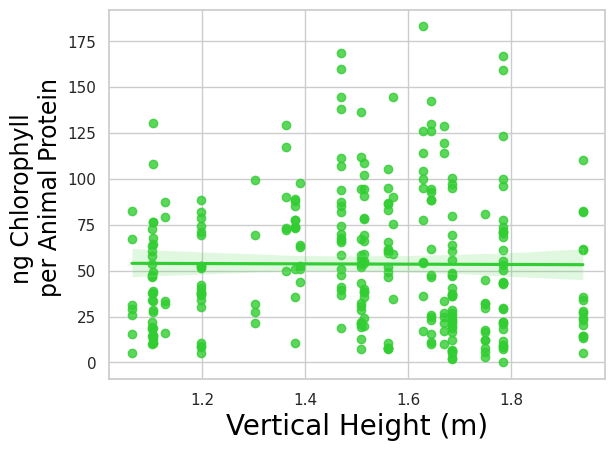

{'slope': -0.8501816958709685,
 'intercept': 54.90980851318592,
 'r_value': -0.0056682249413531624,
 'p_value': 0.9221169421698926,
 'std_err': 8.688595219316369}

In [ ]:
linear_regression_plot(final_chl_data, 'vertical_tidal_height', 'ng_chlorophyll_per_ug_protein')